# Consigna del desafío 4

Replicar y extender el traductor:
- Replicar el modelo en PyTorch.
- Extender el entrenamiento a más datos y tamaños de
secuencias mayores.
- Explorar el impacto de la cantidad de neuronas en
las capas recurrentes.
- Mostrar 5 ejemplos de traducciones generadas.
- Extras que se pueden probar: Embeddings
pre-entrenados para los dos idiomas; cambiar la
estrategia de generación (por ejemplo muestreo
aleatorio);

---
# Imports
---

In [ ]:
import numpy as np
import pandas as pd
import re
import os
import sys
import torch
from torch.nn.utils.rnn import pad_sequence
import torch.nn.functional as F
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

import nltk
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
import string
import gdown

import logging
import os
from pathlib import Path
from io import StringIO
import pickle

import seaborn as sns
import matplotlib.pyplot as plt

!pip3 install torchinfo
from torchinfo import summary

In [ ]:
 nltk.download('punkt')
 nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

---
# Dataset
---

In [ ]:
if os.access('spa-eng', os.F_OK) is False:
    if os.access('spa-eng.zip', os.F_OK) is False:
        !curl -L -o 'spa-eng.zip' 'http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip'
    !unzip -q spa-eng.zip
else:
    print("El dataset ya se encuentra descargado")

text_file = "./spa-eng/spa.txt"

with open(text_file) as f:
    lines = f.read().split("\n")[:-1]

MAX_NUM_SENTENCES = 6000

np.random.seed([40])
np.random.shuffle(lines)

input_sentences = []
output_sentences = []
output_sentences_inputs = []
count = 0

for line in lines:
    count += 1
    if count > MAX_NUM_SENTENCES:
        break

    if '\t' not in line:
        continue

    input_sentence, output = line.rstrip().split('\t')

    output_sentence = output + ' <eos>'
    output_sentences_input = '<sos> ' + output

    input_sentences.append(input_sentence)
    output_sentences.append(output_sentence)
    output_sentences_inputs.append(output_sentences_input)

print("Cantidad de rows disponibles:", len(lines))
print("Cantidad de rows utilizadas:", len(input_sentences))

El dataset ya se encuentra descargado
Cantidad de rows disponibles: 118964
Cantidad de rows utilizadas: 6000


In [ ]:
input_sentences[0], output_sentences[0], output_sentences_inputs[0]

('A deal is a deal.',
 'Un trato es un trato. <eos>',
 '<sos> Un trato es un trato.')

---
# Preprocesamiento
---

In [ ]:
MAX_VOCAB_SIZE = 8000

In [ ]:
def word_tokenizer(sentences):
  all_words = []
  tokenized_sentences = []

  for sentence in sentences:
    tokenized_sentence = word_tokenize(sentence.lower())
    words_only = [word for word in tokenized_sentence if word.isalpha()]

    tokenized_sentences.append(words_only)
    all_words.extend(words_only)

  fdist = FreqDist(all_words)

  most_common_words = [word for word, count in fdist.most_common(MAX_VOCAB_SIZE - 2)]

  word2idx = {word: i + 2 for i, word in enumerate(most_common_words)}
  word2idx['<PAD>'] = 0
  word2idx['<UNK>'] = 1

  integer_seq = []
  for sentence_tokens in tokenized_sentences:
      # Si la palabra no está en el vocabulario, usamos el índice 1 (<UNK>)
      seq = [word2idx.get(word, 1) for word in sentence_tokens]
      integer_seq.append(seq)

  print("Palabras en el vocabulario:", len(word2idx))

  max_input_len = max(len(sen) for sen in integer_seq) if integer_seq else 0
  print("Sentencia de entrada más larga:", max_input_len)

  return integer_seq, word2idx

## Tokenizador ingles

In [ ]:
input_integer_seq, input_word2idx = word_tokenizer(input_sentences)

Palabras en el vocabulario: 3709
Sentencia de entrada más larga: 32


## Tokenizador español

In [ ]:
# Unificamos las frases de entrada y salida del decodificador
all_spanish_sentences = output_sentences_inputs + output_sentences

# Creamos un único tokenizador y vocabulario para el español
output_integer_seq_unified, spanish_word2idx = word_tokenizer(all_spanish_sentences)
num_words_output = len(spanish_word2idx)

# Ahora, usamos este vocabulario único para tokenizar las secuencias por separado
# (Esto es necesario porque la función word_tokenizer hace todo a la vez)
output_input_integer_seq, _ = word_tokenizer(output_sentences_inputs)
output_integer_seq, _ = word_tokenizer(output_sentences)

Palabras en el vocabulario: 5632
Sentencia de entrada más larga: 36
Palabras en el vocabulario: 5631
Sentencia de entrada más larga: 36
Palabras en el vocabulario: 5632
Sentencia de entrada más larga: 36


## Padding

In [ ]:
def pad_sequences_manual(sequences, maxlen, padding='pre', value=0):
    """
    Función que replica el comportamiento de keras.pad_sequences.

    :param sequences: Lista de listas (las secuencias de enteros).
    :param maxlen: Longitud máxima de todas las secuencias.
    :param padding: 'pre' (inicio) o 'post' (final) para el relleno.
    :param value: El valor a usar para el relleno.
    :return: Un array de NumPy con las secuencias rellenadas.
    """
    padded_data = []
    for seq in sequences:
        if len(seq) > maxlen:
            if padding == 'pre':
                new_seq = seq[-maxlen:]
            else: # 'post'
                new_seq = seq[:maxlen]
        else:
            padding_needed = maxlen - len(seq)
            if padding == 'pre':
                new_seq = [value] * padding_needed + seq
            else: # 'post'
                new_seq = seq + [value] * padding_needed
        padded_data.append(new_seq)

    return np.array(padded_data)


In [ ]:
max_input_len = 18
max_out_len = 20

In [ ]:
encoder_input_sequences = pad_sequences_manual(
    input_integer_seq,
    maxlen=max_input_len
)
print("encoder_input_sequences shape:", encoder_input_sequences.shape)

decoder_input_sequences = pad_sequences_manual(
    output_input_integer_seq,
    maxlen=max_out_len,
    padding='post'
)
print("decoder_input_sequences shape:", decoder_input_sequences.shape)

encoder_input_sequences shape: (6000, 18)
decoder_input_sequences shape: (6000, 20)


In [ ]:
decoder_output_sequences = pad_sequences_manual(
    output_integer_seq,
    maxlen=max_out_len,
    padding='post'
)

---
# Embeddings
---

In [ ]:
if os.access('gloveembedding.pkl', os.F_OK) is False:
    url = 'https://drive.google.com/uc?id=1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94&export=download'
    output = 'gloveembedding.pkl'
    gdown.download(url, output, quiet=False)
else:
    print("Los embeddings gloveembedding.pkl ya están descargados")

Los embeddings gloveembedding.pkl ya están descargados


In [ ]:
class WordsEmbeddings(object):
    logger = logging.getLogger(__name__)

    def __init__(self):
        # load the embeddings
        words_embedding_pkl = Path(self.PKL_PATH)
        if not words_embedding_pkl.is_file():
            words_embedding_txt = Path(self.WORD_TO_VEC_MODEL_TXT_PATH)
            assert words_embedding_txt.is_file(), 'Words embedding not available'
            embeddings = self.convert_model_to_pickle()
        else:
            embeddings = self.load_model_from_pickle()
        self.embeddings = embeddings
        # build the vocabulary hashmap
        index = np.arange(self.embeddings.shape[0])
        # Dicctionarios para traducir de embedding a IDX de la palabra
        self.word2idx = dict(zip(self.embeddings['word'], index))
        self.idx2word = dict(zip(index, self.embeddings['word']))

    def get_words_embeddings(self, words):
        words_idxs = self.words2idxs(words)
        return self.embeddings[words_idxs]['embedding']

    def words2idxs(self, words):
        return np.array([self.word2idx.get(word, -1) for word in words])

    def idxs2words(self, idxs):
        return np.array([self.idx2word.get(idx, '-1') for idx in idxs])

    def load_model_from_pickle(self):
        self.logger.debug(
            'loading words embeddings from pickle {}'.format(
                self.PKL_PATH
            )
        )
        max_bytes = 2**28 - 1 # 256MB
        bytes_in = bytearray(0)
        input_size = os.path.getsize(self.PKL_PATH)
        with open(self.PKL_PATH, 'rb') as f_in:
            for _ in range(0, input_size, max_bytes):
                bytes_in += f_in.read(max_bytes)
        embeddings = pickle.loads(bytes_in)
        self.logger.debug('words embeddings loaded')
        return embeddings

    def convert_model_to_pickle(self):
        # create a numpy strctured array:
        # word     embedding
        # U50      np.float32[]
        # word_1   a, b, c
        # word_2   d, e, f
        # ...
        # word_n   g, h, i
        self.logger.debug(
            'converting and loading words embeddings from text file {}'.format(
                self.WORD_TO_VEC_MODEL_TXT_PATH
            )
        )
        structure = [('word', np.dtype('U' + str(self.WORD_MAX_SIZE))),
                     ('embedding', np.float32, (self.N_FEATURES,))]
        structure = np.dtype(structure)
        # load numpy array from disk using a generator
        with open(self.WORD_TO_VEC_MODEL_TXT_PATH, encoding="utf8") as words_embeddings_txt:
            embeddings_gen = (
                (line.split()[0], line.split()[1:]) for line in words_embeddings_txt
                if len(line.split()[1:]) == self.N_FEATURES
            )
            embeddings = np.fromiter(embeddings_gen, structure)
        # add a null embedding
        null_embedding = np.array(
            [('null_embedding', np.zeros((self.N_FEATURES,), dtype=np.float32))],
            dtype=structure
        )
        embeddings = np.concatenate([embeddings, null_embedding])
        # dump numpy array to disk using pickle
        max_bytes = 2**28 - 1 # # 256MB
        bytes_out = pickle.dumps(embeddings, protocol=pickle.HIGHEST_PROTOCOL)
        with open(self.PKL_PATH, 'wb') as f_out:
            for idx in range(0, len(bytes_out), max_bytes):
                f_out.write(bytes_out[idx:idx+max_bytes])
        self.logger.debug('words embeddings loaded')
        return embeddings


class GloveEmbeddings(WordsEmbeddings):
    WORD_TO_VEC_MODEL_TXT_PATH = 'glove.twitter.27B.50d.txt'
    PKL_PATH = 'gloveembedding.pkl'
    N_FEATURES = 50
    WORD_MAX_SIZE = 60

class FasttextEmbeddings(WordsEmbeddings):
    WORD_TO_VEC_MODEL_TXT_PATH = 'cc.en.300.vec'
    PKL_PATH = 'fasttext.pkl'
    N_FEATURES = 300
    WORD_MAX_SIZE = 60

In [ ]:
model_embeddings = GloveEmbeddings()

In [ ]:
print('preparing embedding matrix...')
embed_dim = model_embeddings.N_FEATURES
words_not_found = []

nb_words = min(MAX_VOCAB_SIZE, len(input_word2idx)) # vocab_size
embedding_matrix = np.zeros((nb_words, embed_dim))
for word, i in input_word2idx.items():
    if i >= nb_words:
        continue
    embedding_vector = model_embeddings.get_words_embeddings(word)[0]
    if (embedding_vector is not None) and len(embedding_vector) > 0:

        embedding_matrix[i] = embedding_vector
    else:
        # words not found in embedding index will be all-zeros.
        words_not_found.append(word)

print('number of null word embeddings:', np.sum(np.sum(embedding_matrix**2, axis=1) == 0))

preparing embedding matrix...
number of null word embeddings: 0


In [ ]:
embedding_matrix.shape

(3709, 50)

---
# Entrenar modelo
---

In [ ]:
class TraductorDataset(torch.utils.data.Dataset):
  def __init__(self, encoder_input_data, decoder_input_data, decoder_output):
      self.encoder_input_data = torch.from_numpy(encoder_input_data).long()
      self.decoder_input_data = torch.from_numpy(decoder_input_data).long()

      self.decoder_output = torch.from_numpy(decoder_output).long()

      self.len = self.decoder_output.shape[0]

  def __getitem__(self, index):
      encoder_input = self.encoder_input_data[index]
      decoder_input = self.decoder_input_data[index]
      decoder_output = self.decoder_output[index]

      return encoder_input, decoder_input, decoder_output

  def __len__(self):
      return self.len

In [ ]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, dropout_p=0.5):
        super().__init__()
        self.lstm_size = 256
        self.num_layers = 3
        self.embedding_dim = embed_dim
        self.embedding = nn.Embedding(vocab_size, self.embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        self.embedding.weight.requires_grad = False  # marcar como layer no entrenable (freeze)
        self.dropout = nn.Dropout(dropout_p)
        self.lstm = nn.LSTM(self.embedding_dim, self.lstm_size, self.num_layers,
                            batch_first=True)

    def forward(self, input_seq):
      embedded = self.embedding(input_seq)
      dropped = self.dropout(embedded)
      output, (hidden, cell) = self.lstm(dropped)
      return hidden, cell

In [ ]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, output_dim, dropout_p=0.5):
        super().__init__()
        self.lstm_size = 256
        self.num_layers = 3
        self.embedding_dim = embed_dim
        self.output_dim = output_dim

        # ¡CORRECCIÓN! Usa el vocabulario correcto (español)
        self.embedding = nn.Embedding(vocab_size, self.embedding_dim)
        self.dropout = nn.Dropout(dropout_p)
        self.lstm = nn.LSTM(self.embedding_dim, self.lstm_size, self.num_layers,
                            batch_first=True)
        self.fc = nn.Linear(self.lstm_size, self.output_dim)
        # El softmax se aplica implícitamente en CrossEntropyLoss, es mejor quitarlo
        # self.softmax = nn.Softmax(dim=1)

    def forward(self, x, prev_state):
        out = self.embedding(x)
        dropped = self.dropout(out)
        lstm_output, (ht, ct) = self.lstm(dropped, prev_state)
        # Quita el softmax de aquí
        out = self.fc(lstm_output[:, -1, :])
        return out, (ht, ct)

In [ ]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

        assert encoder.lstm_size == decoder.lstm_size, \
            "Hidden dimensions of encoder and decoder must be equal!"
        assert encoder.num_layers == decoder.num_layers, \
            "Encoder and decoder must have equal number of layers!"

    def forward(self, encoder_input_data, decoder_input_data):
        batch_size = decoder_input_data.shape[0]
        decoder_input_len = decoder_input_data.shape[1]
        vocab_size = self.decoder.output_dim

        outputs = torch.zeros(batch_size, decoder_input_len, vocab_size).to(device)

        hidden, cell = self.encoder(encoder_input_data)

        # Usamos el primer token <sos> de la secuencia de entrada del decodificador
        input = decoder_input_data[:, 0:1]

        for t in range(decoder_input_len):
            output, (hidden, cell) = self.decoder(input, (hidden, cell))
            outputs[:, t, :] = output

            # Para el "teacher forcing", usamos el siguiente token real como entrada
            # en el siguiente paso de tiempo
            input = decoder_input_data[:, t:t+1]

        return outputs

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(device)

cuda


In [ ]:
traductor_dataset = TraductorDataset(encoder_input_sequences,
                                     decoder_input_sequences,
                                     decoder_output_sequences)


In [ ]:
torch.manual_seed(42)

valid_set_size = int(traductor_dataset.len * 0.2)
train_set_size = traductor_dataset.len - valid_set_size

train_set = torch.utils.data.Subset(traductor_dataset, range(train_set_size))
valid_set = torch.utils.data.Subset(traductor_dataset,
                                    range(train_set_size, traductor_dataset.len))


train_loader = torch.utils.data.DataLoader(train_set, batch_size=32, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size=32, shuffle=False)

In [ ]:
nb_words_encoder = len(input_word2idx)

encoder = Encoder(nb_words_encoder).to(device)
decoder = Decoder(num_words_output, num_words_output).to(device)
model = Seq2Seq(encoder, decoder)
model = model.to(device)

In [ ]:
input_data_encoder = traductor_dataset[0:1][0].to(device)
input_data_decoder = traductor_dataset[0:1][1].to(device)

summary(model, input_data=(input_data_encoder, input_data_decoder))

Layer (type:depth-idx)                   Output Shape              Param #
Seq2Seq                                  [1, 20, 5632]             --
├─Encoder: 1-1                           [3, 1, 256]               --
│    └─Embedding: 2-1                    [1, 18, 50]               (185,450)
│    └─Dropout: 2-2                      [1, 18, 50]               --
│    └─LSTM: 2-3                         [1, 18, 256]              1,368,064
├─Decoder: 1-2                           [1, 5632]                 --
│    └─Embedding: 2-4                    [1, 1, 50]                281,600
│    └─Dropout: 2-5                      [1, 1, 50]                --
│    └─LSTM: 2-6                         [1, 1, 256]               1,368,064
│    └─Linear: 2-7                       [1, 5632]                 1,447,424
├─Decoder: 1-3                           [1, 5632]                 (recursive)
│    └─Embedding: 2-8                    [1, 1, 50]                (recursive)
│    └─Dropout: 2-9               

In [ ]:
def sequence_acc(y_pred, y_test):
    y_pred_tag = y_pred.argmax(dim=1)
    correct_results_sum = (y_pred_tag == y_test).sum().float()
    acc = correct_results_sum / y_test.shape[0]
    return acc

In [ ]:
def train(model, train_loader, valid_loader, epochs=100, optimizer=None, criterion=None, patience=5):
  train_loss = []
  train_accuracy = []
  valid_loss = []
  valid_accuracy = []
  best_valid_loss = float('inf')
  patience_counter = 0

  for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    epoch_train_accuracy = 0

    for encoder_input_data, decoder_input_data, decoder_output in train_loader:
      optimizer.zero_grad()
      encoder_input_data = encoder_input_data.to(device)
      decoder_input_data = decoder_input_data.to(device)
      decoder_output = decoder_output.to(device) # Mueve los objetivos al dispositivo

      output = model(encoder_input_data, decoder_input_data)

      # Reestructura la salida y los objetivos para el cálculo de la pérdida
      output_dim = output.shape[-1]
      output = output.view(-1, output_dim)
      decoder_output = decoder_output.view(-1)

      loss = criterion(output, decoder_output)

      epoch_train_loss += loss.item()

      loss.backward()

      optimizer.step()

      # Calcula la precisión con el formato correcto
      accuracy = sequence_acc(output, decoder_output)
      epoch_train_accuracy += accuracy.item()

    epoch_train_loss = epoch_train_loss / len(train_loader)
    train_loss.append(epoch_train_loss)
    epoch_train_accuracy = epoch_train_accuracy / len(train_loader)
    train_accuracy.append(epoch_train_accuracy)

    model.eval()
    epoch_valid_loss = 0
    epoch_valid_accuracy = 0
    with torch.no_grad(): # Desactiva el cálculo de gradientes para la validación
        for encoder_input_data, decoder_input_data, decoder_output in valid_loader:
            encoder_input_data = encoder_input_data.to(device)
            decoder_input_data = decoder_input_data.to(device)
            decoder_output = decoder_output.to(device)

            output = model(encoder_input_data, decoder_input_data)
            output_dim = output.shape[-1]
            output = output.view(-1, output_dim)
            decoder_output = decoder_output.view(-1)

            loss = criterion(output, decoder_output)

            epoch_valid_loss += loss.item()
            accuracy = sequence_acc(output, decoder_output)
            epoch_valid_accuracy += accuracy.item()

    epoch_valid_loss = epoch_valid_loss / len(valid_loader)
    valid_loss.append(epoch_valid_loss)
    epoch_valid_accuracy = epoch_valid_accuracy / len(valid_loader)
    valid_accuracy.append(epoch_valid_accuracy)

    print(f"Epoch: {epoch+1}/{epochs} - Train loss {epoch_train_loss:.3f} - Train accuracy {epoch_train_accuracy:.3f} - Valid Loss {epoch_valid_loss:.3f} - Valid accuracy {epoch_valid_accuracy:.3f}")

    history = {
      "loss": train_loss,
      "accuracy": train_accuracy,
      "val_loss": valid_loss,
      "val_accuracy": valid_accuracy
    }

    if epoch_valid_loss < best_valid_loss: # Usa la pérdida de validación para early stopping
        best_valid_loss = epoch_valid_loss
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping")
        break

  return history

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = torch.nn.CrossEntropyLoss()

model_history = train(model, train_loader, valid_loader, epochs=200,
                      optimizer=optimizer, criterion=criterion, patience = 15)

Epoch: 1/200 - Train loss 2.667 - Train accuracy 0.653 - Valid Loss 2.214 - Valid accuracy 0.671
Epoch: 2/200 - Train loss 2.172 - Train accuracy 0.668 - Valid Loss 2.199 - Valid accuracy 0.671
Epoch: 3/200 - Train loss 2.106 - Train accuracy 0.678 - Valid Loss 2.142 - Valid accuracy 0.686
Epoch: 4/200 - Train loss 2.066 - Train accuracy 0.686 - Valid Loss 2.119 - Valid accuracy 0.692
Epoch: 5/200 - Train loss 2.034 - Train accuracy 0.691 - Valid Loss 2.101 - Valid accuracy 0.697
Epoch: 6/200 - Train loss 2.006 - Train accuracy 0.695 - Valid Loss 2.091 - Valid accuracy 0.700
Epoch: 7/200 - Train loss 1.982 - Train accuracy 0.698 - Valid Loss 2.083 - Valid accuracy 0.702
Epoch: 8/200 - Train loss 1.960 - Train accuracy 0.699 - Valid Loss 2.080 - Valid accuracy 0.704
Epoch: 9/200 - Train loss 1.937 - Train accuracy 0.702 - Valid Loss 2.071 - Valid accuracy 0.704
Epoch: 10/200 - Train loss 1.909 - Train accuracy 0.705 - Valid Loss 2.064 - Valid accuracy 0.706
Epoch: 11/200 - Train loss 1.

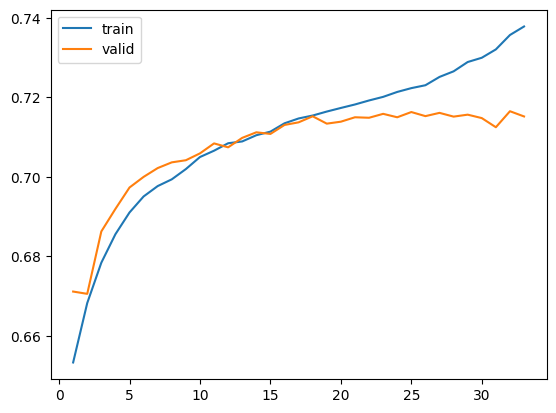

In [ ]:
epoch_count = range(1, len(model_history['accuracy']) + 1)
sns.lineplot(x=epoch_count,  y=model_history['accuracy'], label='train')
sns.lineplot(x=epoch_count,  y=model_history['val_accuracy'], label='valid')
plt.show()